In [1]:
from scipy import optimize
import numpy as np
import matplotlib.pyplot as plt

Questão 1

In [2]:
g = lambda c: (2*c)/(4+c**2+0.2*c**3) 

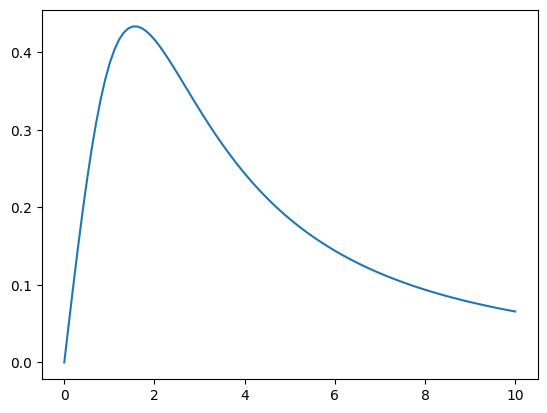

In [3]:
space = np.linspace(0, 10, 100)
plt.plot(space, g(space), label='g(c)')

In [4]:
maximo = optimize.fminbound(lambda c: -g(c), 0, 10)

O crescimento maximo é 0.43 para c = 1.6


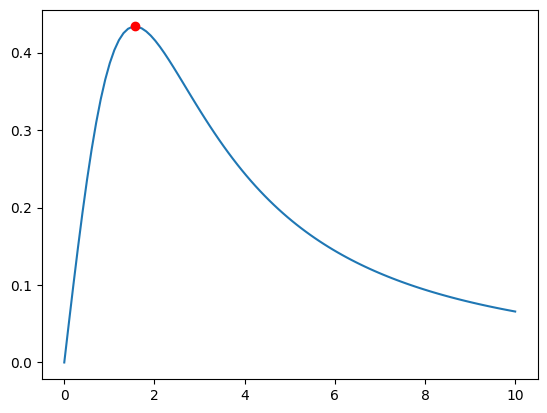

In [5]:
plt.plot(space, g(space), label='g(c)')
plt.plot(maximo, g(maximo), 'ro', label='maximo')
print(f'O crescimento maximo é {g(maximo):.2} para c = {maximo:.2}')

Questão 2



## Sistema de Equações

(1)   0x₁ + 2x₂ + 5x₃ = 9  
(2)   2x₁ + x₂ + x₃ = 9  
(3)   3x₁ + x₂ + 0x₃ = 10

---

## Variáveis Isoladas

- **x₂ = (9 - 5x₃) / 2**   [eq1]  
- **x₃ = 9 - 2x₁ - x₂**   [eq2]  
- **x₁ = (10 - x₂) / 3**  [eq3]

---

## Valores Iniciais

- \( x₁^{(0)} = 0 \)  
- \( x₂^{(0)} = 0 \)  
- \( x₃^{(0)} = 0 \)

---

##  Jacobi

### Iteração 1:
- \( x_1^{(1)} = \frac{10 - 0}{3} = 3.3333 \)
- \( x_2^{(1)} = \frac{9 - 5×0}{2} = 4.5 \)
- \( x_3^{(1)} = 9 - 2×0 - 0 = 9.0 \)

---

### Iteração 2:
- \( x_1^{(2)} = \frac{10 - 4.5}{3} = 1.8333 \)
- \( x_2^{(2)} = \frac{9 - 5×9}{2} = -18.0 \)
- \( x_3^{(2)} = 9 - 2×3.3333 - 4.5 = -2.1667 \)

**Erros relativos da Iteração 2:**

\[
\begin{aligned}
\text{Erro } x_1 &= \left| \frac{1.8333 - 3.3333}{1.8333} \right| = 0.8182 \\
\text{Erro } x_2 &= \left| \frac{-18.0 - 4.5}{-18.0} \right| = 1.25 \\
\text{Erro } x_3 &= \left| \frac{-2.1667 - 9.0}{-2.1667} \right| = 5.154 \\
\end{aligned}
\]

---

### Iteração 3:
- \( x_1^{(3)} = \frac{10 - (-18.0)}{3} = 9.3333 \)
- \( x_2^{(3)} = \frac{9 - 5×(-2.1667)}{2} = 10.4167 \)
- \( x_3^{(3)} = 9 - 2×1.8333 - (-18.0) = 23.3333 \)

**Erros relativos da Iteração 3:**

\[
\begin{aligned}
\text{Erro } x_1 &= \left| \frac{9.3333 - 1.8333}{9.3333} \right| = 0.8036 \\
\text{Erro } x_2 &= \left| \frac{10.4167 - (-18.0)}{10.4167} \right| = 2.727 \\
\text{Erro } x_3 &= \left| \frac{23.3333 - (-2.1667)}{23.3333} \right| = 1.095 \\
\end{aligned}
\]

---

## Gauss-Seidel

### Iteração 1:

- \( x_1^{(1)} = \frac{10 - 0}{3} = 3.3333 \)
- \( x_2^{(1)} = \frac{9 - 5×0}{2} = 4.5 \)
- \( x_3^{(1)} = 9 - 2×3.3333 - 4.5 = -2.1667 \)

### Iteração 2:
- \( x_1^{(2)} = \frac{10 - 4.5}{3} = 1.8333 \)
- \( x_2^{(2)} = \frac{9 - 5×(-2.1667)}{2} = 10.4167 \)
- \( x_3^{(2)} = 9 - 2×1.8333 - 10.4167 = -5.0833 \)

### Iteração 3:
- \( x_1^{(3)} = \frac{10 - 10.4167}{3} = -0.1389 \)
- \( x_2^{(3)} = \frac{9 - 5×(-5.0833)}{2} = 16.2083 \)
- \( x_3^{(3)} = 9 - 2×(-0.1389) - 16.2083 = -6.2083 \)

---

## Verificação

Usando:  
\( x_1 = 9.3333 \),  
\( x_2 = 10.4167 \),  
\( x_3 = 23.3333 \)

- **Eq(1):** \( 2×10.4167 + 5×23.3333 = 20.8334 + 116.6665 = 137.5 \)  
  → **Erro:** \( |137.5 - 9| = 128.5 \)

- **Eq(2):** \( 2×9.3333 + 10.4167 + 23.3333 = 18.6666 + 10.4167 + 23.3333 = 52.4166 \)  
  → **Erro:** \( |52.4166 - 9| = 43.4166 \)

- **Eq(3):** \( 3×9.3333 + 10.4167 = 28.0 + 10.4167 = 38.4167 \)  
  → **Erro:** \( |38.4167 - 10| = 28.4167 \)



---

## Critério de Convergência

Para os métodos iterativos garantirem convergencia, a matriz dos coeficientes deve ser **diagonalmente dominante**:

\[
A =
\begin{bmatrix}
0 & 2 & 5 \\
2 & 1 & 1 \\
3 & 1 & 0
\end{bmatrix}
\]

Verificando linha a linha:

- **Linha 1:** |0| < |2| + |5| = 7 
- **Linha 2:** |1| < |2| + |1| = 3 
- **Linha 3:** |0| < |3| + |1| = 4 

Nenhuma linha é diagonalmente dominante.

Além disso, **não é possível reordenar as equações para obter uma matriz dominante**



Questão 3

In [6]:
A = np.array([
    [15, 17, 19],      
    [0.30, 0.40, 0.55],  
    [1.0, 1.2, 1.5]    
])


b = np.array([3890, 95, 282])


x = np.linalg.solve(A, b)

print("Solução com numpy.linalg.solve (uso exato dos recursos):")
print(f"x1 (componentes tipo 1): {x[0]:.2f}")
print(f"x2 (componentes tipo 2): {x[1]:.2f}")
print(f"x3 (componentes tipo 3): {x[2]:.2f}")


Solução com numpy.linalg.solve (uso exato dos recursos):
x1 (componentes tipo 1): 90.00
x2 (componentes tipo 2): 60.00
x3 (componentes tipo 3): 80.00


In [8]:


L = np.array([
    [ 2, -1,  0, -1,  0],
    [-1,  3, -1, -1,  0],
    [ 0, -1,  1,  0,  0],
    [-1, -1,  0,  3, -1],
    [ 0,  0,  0, -1,  1]
])


b = np.array([100, 0, -100, 0, 0])


x = np.linalg.solve(L, b)

print("Fluxo nos bairros com 100 pessoas entrando no bairro A e saindo no C:")
for bairro, valor in zip(['A', 'B', 'C', 'D', 'E'], x):
    print(f"  Bairro {bairro}: {valor:.2f}")

b_dobrado = np.array([200, 0, -200, 0, 0])
x_dobrado = np.linalg.solve(L, b_dobrado)

print("\nFluxo nos bairros com 200 pessoas entrando no bairro A e saindo no C:")
for bairro, valor in zip(['A', 'B', 'C', 'D', 'E'], x_dobrado):
    print(f"  Bairro {bairro}: {valor:.2f}")


mudanca_B = x_dobrado[1] - x[1]
print(f"\nVariação no fluxo do bairro B ao dobrar a entrada em A: {mudanca_B:.2f}")

Fluxo nos bairros com 100 pessoas entrando no bairro A e saindo no C:
  Bairro A: 76.00
  Bairro B: 9.33
  Bairro C: -90.67
  Bairro D: 42.67
  Bairro E: 42.67

Fluxo nos bairros com 200 pessoas entrando no bairro A e saindo no C:
  Bairro A: 152.00
  Bairro B: 18.67
  Bairro C: -181.33
  Bairro D: 85.33
  Bairro E: 85.33

Variação no fluxo do bairro B ao dobrar a entrada em A: 9.33


Questão 5

In [11]:
A = np.array([
    [225,   0,  -25,   0],
    [  0, 175,    0, -25],
    [-225,  0,  275, -25],
    [  0, -25,  -25, 200]
])


b = np.array([1400, 0, 100, 0])

# a) Concentração de monóxido de carbono em cada sala (mg/m³)
c = np.linalg.solve(A, b)

print("a) Concentração de monóxido de carbono em cada sala (mg/m³):")
for i, val in enumerate(c, 1):
    print(f"  Sala {i}: {val:.2f} mg/m³")

# b) Porcentagem da concentração em c2 vinda de c1, c3, ventilação (b)
# Fonte 1: de c1 → c2 via E12 = 25 (c1 * E12)
# Fonte 2: de c3 → c2 via E32 = 25 (c3 * E32)
# Fonte 3: ventilação externa = Qc * cc = 150 * 0 = 0
contrib_1 = c[0] * 25
contrib_2 = c[2] * 25
contrib_total = contrib_1 + contrib_2
percent_1 = (contrib_1 / contrib_total) * 100
percent_2 = (contrib_2 / contrib_total) * 100

print("\nb) Porcentagem da concentração na Sala 2 proveniente de:")
print(f"  Sala 1: {percent_1:.2f}%")
print(f"  Sala 3: {percent_2:.2f}%")
print(f"  Ventilação externa: 0.00%")

# c) Aumentar fontes: sala 1 (2000 mg/h) e sala 3 (5000 mg/h)
b_aumentado = np.array([2000, 0, 5000, 0])
c_aumentado = np.linalg.solve(A, b_aumentado)

print("\nc) Concentração com cargas aumentadas:")
for i, val in enumerate(c_aumentado, 1):
    print(f"  Sala {i}: {val:.2f} mg/m³")

print(f"\n  Crescimento da concentração na Sala das crianças: {c_aumentado[1] - c[1]:.2f} mg/m³")

# d) Reduzir E24 (mistura entre sala 2 e 4) de 25 para 5 m³/h
A_mod = A.copy()
A_mod[1, 3] = -5
A_mod[3, 1] = -5
A_mod[1, 1] = 155  # 175 - 25 + 5
A_mod[3, 3] = 180  # 200 - 25 + 5

c_mod = np.linalg.solve(A_mod, b)

print("\nd) Concentração com E24 reduzido de 25 para 5 m³/h:")
print(f"  Sala 2: {c_mod[1]:.2f} mg/m³ (antes era {c[1]:.2f} mg/m³)")


a) Concentração de monóxido de carbono em cada sala (mg/m³):
  Sala 1: 6.90 mg/m³
  Sala 2: 0.11 mg/m³
  Sala 3: 6.08 mg/m³
  Sala 4: 0.77 mg/m³

b) Porcentagem da concentração na Sala 2 proveniente de:
  Sala 1: 53.16%
  Sala 3: 46.84%
  Ventilação externa: 0.00%

c) Concentração com cargas aumentadas:
  Sala 1: 12.04 mg/m³
  Sala 2: 0.52 mg/m³
  Sala 3: 28.36 mg/m³
  Sala 4: 3.61 mg/m³

  Crescimento da concentração na Sala das crianças: 0.41 mg/m³

d) Concentração com E24 reduzido de 25 para 5 m³/h:
  Sala 2: 0.03 mg/m³ (antes era 0.11 mg/m³)
